In [1]:
import pickle
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [2]:
with open("../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [3]:
# Se copian los datos
df_model = df_data.copy()

# Se agrupan los datos por estaciones y por intervalo de tiempo

In [4]:
df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')

df_model['datetime_hour'].head(10)

C:\Users\burvu\AppData\Local\Temp\ipykernel_15288\1090642612.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')


0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-01
6   2022-01-01
7   2022-01-01
8   2022-01-01
9   2022-01-01
Name: datetime_hour, dtype: datetime64[ns]

In [5]:
# Agregar los viajes
df_counts = df_model.groupby(
    ['start_station_idx', 'end_station_idx', 'datetime_hour']
).agg({
    'temp_std': 'mean',
    'wind_std': 'mean',
    'rel_humidity_std': 'mean',
    'event': 'first',
    'day_type_Holiday': 'first',
    'day_type_Normal': 'first',
    'day_type_Weekend': 'first',
    'hour_float': 'first',
    'hour_sin': 'first',
    'hour_cos': 'first',
    'month_sin': 'first',
    'month_cos': 'first',
    'year': 'first',
    # cuenta de viajes
    'start_station_idx': 'count'
}).rename(columns={'start_station_idx': 'trip_count'}).reset_index()

In [6]:
X_context = df_counts[['temp_std', 'wind_std', 'rel_humidity_std', 'event', 'day_type_Holiday', 'day_type_Normal', 'day_type_Weekend', 'hour_float', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'year']]
X_start = df_counts['start_station_idx']
X_end = df_counts['end_station_idx']
y = df_counts['trip_count']

In [7]:
with open("../data/normalized/le_station_encoder.pkl", "rb") as f: 
    le_station = pickle.load(f)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# 1. Parámetros
# ------------------------------------------------------------
num_stations = len(le_station.classes_)
num_features = X_context.shape[1]
embed_dim = int(np.ceil(np.sqrt(num_stations)))
seq_length = 24
hidden_units = 64

# ------------------------------------------------------------
# 2. Crear secuencias por par origen–destino
# ------------------------------------------------------------
def create_sequences_by_pair(df, seq_len):
    Xs_start, Xs_end, Xs_context, ys = [], [], [], []

    grouped = df.groupby(['start_station_idx', 'end_station_idx'])
    for (start_idx, end_idx), group in grouped:
        group = group.sort_values('datetime_hour')
        X_context = group[['temp_std', 'wind_std', 'rel_humidity_std',
                           'event', 'day_type_Holiday', 'day_type_Normal',
                           'day_type_Weekend', 'hour_float', 'hour_sin',
                           'hour_cos', 'month_sin', 'month_cos', 'year']].values
        y_vals = np.log1p(group['trip_count'].values)

        # Saltar pares muy cortos
        if len(group) <= seq_len:
            continue

        for i in range(len(group) - seq_len):
            Xs_start.append(start_idx)
            Xs_end.append(end_idx)
            Xs_context.append(X_context[i:i+seq_len])
            ys.append(y_vals[i+seq_len])

    return (
        np.array(Xs_start),
        np.array(Xs_end),
        np.array(Xs_context),
        np.array(ys)
    )

X_start_seq, X_end_seq, X_context_seq, y_seq = create_sequences_by_pair(df_counts, seq_length)

print(f"Total de secuencias creadas: {len(X_context_seq):,}")

# ------------------------------------------------------------
# 3. Definición del modelo GRU
# ------------------------------------------------------------
input_start = Input(shape=(1,), name='start_station')
input_end = Input(shape=(1,), name='end_station')
input_context = Input(shape=(seq_length, num_features), name='context_sequence')

# Embeddings
embed_start = layers.Embedding(num_stations, embed_dim)(input_start)
embed_end = layers.Embedding(num_stations, embed_dim)(input_end)
flat_start = layers.Flatten()(embed_start)
flat_end = layers.Flatten()(embed_end)

# Capa GRU sobre las secuencias de contexto
x = layers.GRU(hidden_units, return_sequences=False)(input_context)
x = layers.Dense(64, activation='relu')(x)

# Concatenación embeddings + salida GRU
x = layers.Concatenate()([x, flat_start, flat_end])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

# Salida
output = layers.Dense(1, activation='linear')(x)

# Modelo
model = Model(inputs=[input_start, input_end, input_context], outputs=output)
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model.summary()


Total de secuencias creadas: 6,452,548


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ context_sequence    │ (None, 24, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     15,168 │ context_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 42)     │     71,190 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 42)     │     71,190 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 42)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 42)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 148)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      9,536 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 173,357 (677.18 KB)

 Trainable params: 173,357 (677.18 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
print(X_start_seq.dtype, X_end_seq.dtype, X_context_seq.dtype, y_seq.dtype)

int64 int64 object float64


In [15]:
# Asegurar tipos correctos
X_start_seq = X_start_seq.astype(np.int32)
X_end_seq = X_end_seq.astype(np.int32)
X_context_seq = X_context_seq.astype(np.float32)
y_seq = y_seq.astype(np.float32)

In [16]:
# ------------------------------------------------------------
# 4. Entrenamiento
# ------------------------------------------------------------
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    {'start_station': X_start_seq,
     'end_station': X_end_seq,
     'context_sequence': X_context_seq},
    y_seq,
    validation_split=0.2,
    batch_size=64,
    epochs=5,
    callbacks=[callback]
)

Epoch 1/5
80657/80657 ━━━━━━━━━━━━━━━━━━━━ 602s 7ms/step - loss: 0.0294 - mae: 0.1001 - val_loss: 0.0278 - val_mae: 0.1054
Epoch 2/5
80657/80657 ━━━━━━━━━━━━━━━━━━━━ 549s 7ms/step - loss: 0.0290 - mae: 0.0994 - val_loss: 0.0294 - val_mae: 0.1206
Epoch 3/5
80657/80657 ━━━━━━━━━━━━━━━━━━━━ 559s 7ms/step - loss: 0.0290 - mae: 0.0993 - val_loss: 0.0296 - val_mae: 0.1266
Epoch 4/5
80657/80657 ━━━━━━━━━━━━━━━━━━━━ 564s 7ms/step - loss: 0.0289 - mae: 0.0993 - val_loss: 0.0331 - val_mae: 0.1437


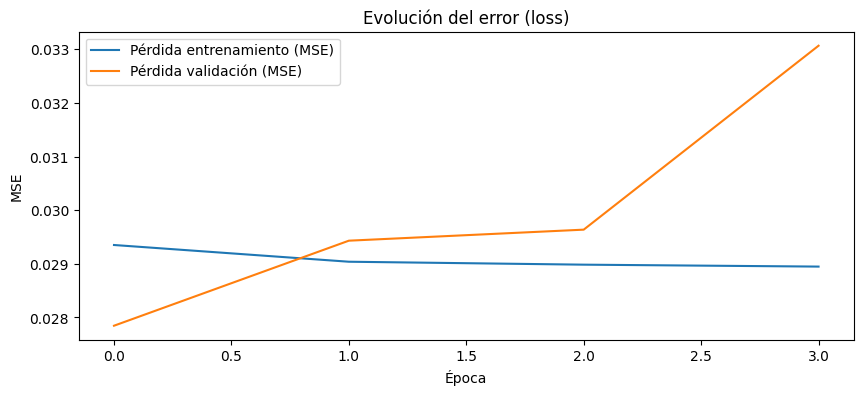

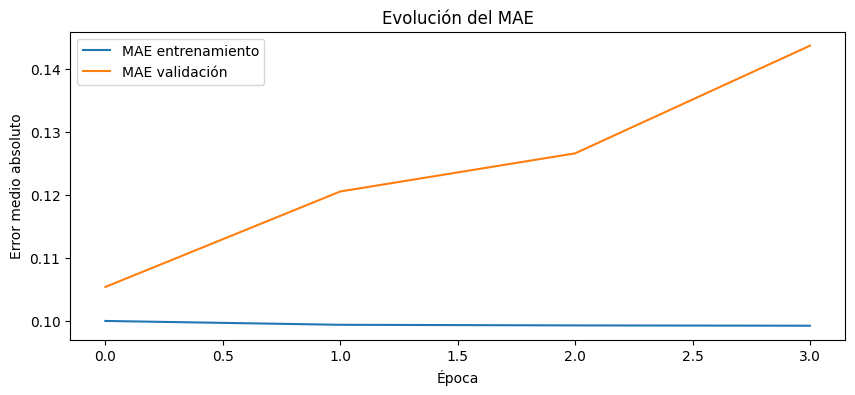

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Pérdida entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida validación (MSE)')
plt.legend()
plt.title("Evolución del error (loss)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='MAE entrenamiento')
plt.plot(history.history['val_mae'], label='MAE validación')
plt.legend()
plt.title("Evolución del MAE")
plt.xlabel("Época")
plt.ylabel("Error medio absoluto")
plt.show()


In [20]:
test_loss, test_mae = model.evaluate(
    {'start_station': X_start_seq,
     'end_station': X_end_seq,
     'context_sequence': X_context_seq},
    y_seq,
    verbose=0
)

print(f"Error cuadrático medio (MSE): {test_loss:.4f}")
print(f"Error absoluto medio (MAE): {test_mae:.4f}")


Error cuadrático medio (MSE): 0.0289
Error absoluto medio (MAE): 0.1016


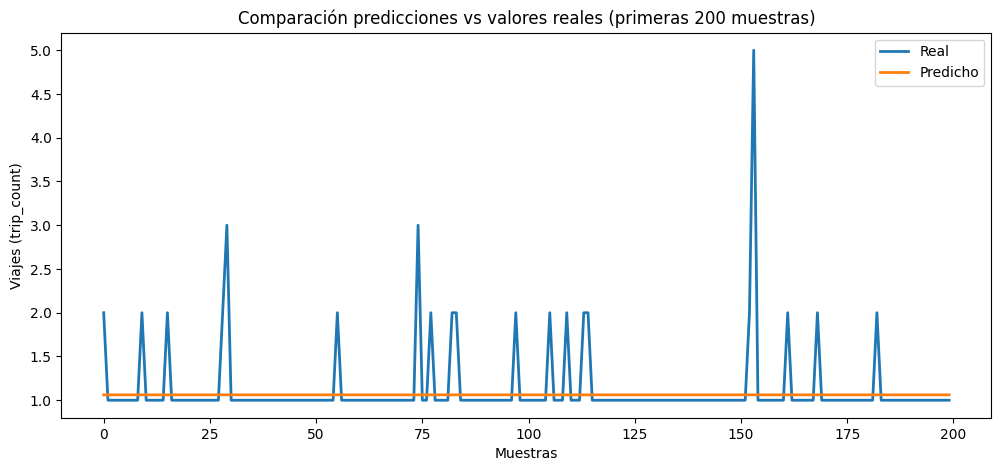

MAE  : 0.2529
RMSE : 0.5324
R²   : 0.1095

Tiempo de inferencia por muestra: 107.854 ms


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# 1️⃣ Predicciones en todo el conjunto
# ------------------------------------------------------------
y_pred = model.predict(
    {
        'start_station': X_start_seq,
        'end_station': X_end_seq,
        'context_sequence': X_context_seq
    },
    verbose=0
)

# Volver a la escala original (si entrenaste con log1p)
y_real = np.expm1(y_seq)
y_pred_real = np.expm1(y_pred)

# ------------------------------------------------------------
# 2️⃣ Evaluación visual (comparar real vs predicho)
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_real[:200], label='Real', linewidth=2)
plt.plot(y_pred_real[:200], label='Predicho', linewidth=2)
plt.legend()
plt.title("Comparación predicciones vs valores reales (primeras 200 muestras)")
plt.xlabel("Muestras")
plt.ylabel("Viajes (trip_count)")
plt.show()

# ------------------------------------------------------------
# 3️⃣ Métricas numéricas de desempeño
# ------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))
r2 = r2_score(y_real, y_pred_real)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ------------------------------------------------------------
# 4️⃣ Medición del tiempo de inferencia
# ------------------------------------------------------------
sample = {
    'start_station': X_start_seq[:1],
    'end_station': X_end_seq[:1],
    'context_sequence': X_context_seq[:1]
}

t0 = time.perf_counter()
y_sample_pred = model.predict(sample, verbose=0)
t1 = time.perf_counter()

inference_time = (t1 - t0) * 1000  # milisegundos
print(f"\nTiempo de inferencia por muestra: {inference_time:.3f} ms")
